# Encoder-Only Representation Learning — Lorenz (Single Run)

Trains a causal sequence encoder (Transformer / SSM / TCN) on Lorenz attractors
**without** the downstream JacobianODE, using same-state reconstruction and/or
next-state prediction as self-supervised objectives.

Optional regularisation losses:
- **FNN** – false-nearest-neighbour (Gilpin NeurIPS 2020)
- **Amplification** – noise amplification in embedding space
- **DeCov** – off-diagonal covariance penalty (Cogswell ICLR 2016)

Edit the variable blocks in *Section 2* (data, encoder, training, regularisation)
to quickly experiment with different architectures, latent dimensions, or
regularisation strengths. Default encoder: **SSM** (LRU).

## 1 — Environment Setup

In [29]:
import sys, os
# Add repo root to path when running from _jupyter/
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from hydra.utils import instantiate

# Core pipeline utilities (shared with JacobianODE)
from JacobianODE.jacobians.core import seed_everything
from JacobianODE.jacobians.data import make_trajectories, postprocess_data, create_dataloaders
from JacobianODE.jacobians.training import train_model
from JacobianODE.jacobians.training.logging import log_training_info

# Encoder-only utilities
from JacobianODE.encoder_only.config import load_encoder_config

torch.set_float32_matmul_precision('high')
print(f'PyTorch {torch.__version__}  |  GPUs: {torch.cuda.device_count()}')

PyTorch 2.10.0+cu128  |  GPUs: 1


## 2 — Configuration

Define hyperparameters as variables below, then build overrides from them.  
**Default:** SSM (LRU) encoder. For transformer/tcn, set `MODEL` and adjust encoder vars.

In [30]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR     = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoders"
WANDB_ENTITY = "JacobianODE"
WANDB_PROJECT   = "LorenzPartial__Encoder"
WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

In [31]:
# ----------------------------------------------------------------
# Data hyperparameters
# ----------------------------------------------------------------
NUM_ICS          = 32
N_PERIODS        = 12
PTS_PER_PERIOD   = 100
SEQ_LENGTH       = 100
OBS_NOISE        = 0.05

# Partial observation (same as hyperparameter tuning notebook)
# OBSERVED_INDICES = [0, 1, 2]   # Observe ALL three Lorenz dimensions; use [0] for x-only
OBSERVED_INDICES = [0]
# N_DELAYS         = 1           # Number of delays for delay embedding (1 = no embedding)
N_DELAYS         = 43
DELAY_SPACING    = 1           # Spacing between delays when N_DELAYS > 1

In [32]:
# ----------------------------------------------------------------
# Encoder / architecture hyperparameters (default: SSM)
# ----------------------------------------------------------------
MODEL = 'ssm'   # ssm | transformer | tcn

N_LATENT = 10

# SSM (LRU) parameters — used when MODEL='ssm'
SSM_D_MODEL    = 128
SSM_D_STATE    = 64
SSM_N_LAYERS   = 3
# SSM_R_MIN      = 0.0
# SSM_R_MAX      = 0.99
SSM_R_MIN = 0.9
SSM_R_MAX = 0.999
SSM_FFN_EXPAND = 4
SSM_DROPOUT    = 0.1

# Transformer parameters — used when MODEL='transformer'
TRANSFORMER_D_MODEL       = 64
TRANSFORMER_N_HEADS       = 4
TRANSFORMER_N_LAYERS      = 3
TRANSFORMER_DIM_FEEDFORWARD = 128
TRANSFORMER_DROPOUT       = 0.1

# TCN parameters — used when MODEL='tcn'
TCN_N_CHANNELS = 64
TCN_KERNEL_SIZE = 7
TCN_N_LAYERS   = 4
TCN_DROPOUT    = 0.1

# Decoder head (shared across architectures)
USE_SAME_STATE_DECODER = True
USE_NEXT_STATE_DECODER = True
DECODER_HIDDEN_DIM    = 128
DECODER_N_LAYERS      = 2
# Burn-in for next-state prediction: skip first N steps (partial obs may need context)
NEXT_STATE_BURN_IN    = 0

In [33]:
# ----------------------------------------------------------------
# Training hyperparameters
# ----------------------------------------------------------------
BATCH_SIZE               = 32
LEARNING_RATE            = 1e-4
MAX_EPOCHS               = 200
LIMIT_TRAIN_BATCHES      = 200
EARLY_STOPPING_PATIENCE  = 2     # Patience for percent-thresh early stopping
PERCENT_THRESH           = 0.01  # Min. percent improvement required (percent_thresh mode)

# ----------------------------------------------------------------
# Regularisation weights (0 to disable)
# ----------------------------------------------------------------
FNN_WEIGHT           = 0.0   # FNN latent-geometry regulariser (Gilpin NeurIPS 2020)
AMPLIFICATION_WEIGHT = 0.0   # Noise amplification regulariser
DECOV_WEIGHT         = 0.0   # DeCov off-diagonal covariance penalty (Cogswell ICLR 2016)

In [34]:
# Format list-valued overrides without spaces so they double as valid Hydra CLI args
_obs_idx_str = str(list(OBSERVED_INDICES)).replace(' ', '')

# Build overrides from variables (matches hyperparameter tuning notebook pattern)
overrides = [
    # --- Model: SSM (LRU) encoder ---
    f"model={MODEL}",
    f"++model.encoder.n_latent={N_LATENT}",
    f"++model.use_same_state_decoder={str(USE_SAME_STATE_DECODER).lower()}",
    f"++model.use_next_state_decoder={str(USE_NEXT_STATE_DECODER).lower()}",
    f"++model.decoder_hidden_dim={DECODER_HIDDEN_DIM}",
    f"++model.decoder_n_layers={DECODER_N_LAYERS}",
    f"++model.next_state_burn_in={NEXT_STATE_BURN_IN}",
]

# Architecture-specific encoder overrides
if MODEL == 'ssm':
    overrides.extend([
        f"++model.encoder.d_model={SSM_D_MODEL}",
        f"++model.encoder.d_state={SSM_D_STATE}",
        f"++model.encoder.n_layers={SSM_N_LAYERS}",
        f"++model.encoder.r_min={SSM_R_MIN}",
        f"++model.encoder.r_max={SSM_R_MAX}",
        f"++model.encoder.ffn_expand={SSM_FFN_EXPAND}",
        f"++model.encoder.dropout={SSM_DROPOUT}",
    ])
elif MODEL == 'transformer':
    overrides.extend([
        f"++model.encoder.d_model={TRANSFORMER_D_MODEL}",
        f"++model.encoder.n_heads={TRANSFORMER_N_HEADS}",
        f"++model.encoder.n_layers={TRANSFORMER_N_LAYERS}",
        f"++model.encoder.dim_feedforward={TRANSFORMER_DIM_FEEDFORWARD}",
        f"++model.encoder.dropout={TRANSFORMER_DROPOUT}",
    ])
elif MODEL == 'tcn':
    overrides.extend([
        f"++model.encoder.n_channels={TCN_N_CHANNELS}",
        f"++model.encoder.kernel_size={TCN_KERNEL_SIZE}",
        f"++model.encoder.n_layers={TCN_N_LAYERS}",
        f"++model.encoder.dropout={TCN_DROPOUT}",
    ])

overrides.extend([
    # --- Paths and W&B (from Section 2 variables) ---
    f"training.logger.save_dir={SAVE_DIR}",
    f"wandb_entity={WANDB_ENTITY}",
    f"wandb_project={WANDB_PROJECT}",
    # --- Regularisation ---
    f"++training.lightning.fnn_weight={FNN_WEIGHT}",
    f"++training.lightning.amplification_weight={AMPLIFICATION_WEIGHT}",
    f"++training.lightning.decov_weight={DECOV_WEIGHT}",
    # --- Training ---
    f"++training.batch_size={BATCH_SIZE}",
    f"++training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"++training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"++training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"++training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
    f"++training.early_stopping.percent_thresh={PERCENT_THRESH}",
    # --- Data ---
    f"++data.trajectory_params.num_ics={NUM_ICS}",
    f"++data.trajectory_params.n_periods={N_PERIODS}",
    f"++data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"++data.train_test_params.seq_length={SEQ_LENGTH}",
    f"++data.postprocessing.obs_noise={OBS_NOISE}",
    # --- Partial observation / delay embedding ---
    f"++data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    f"++data.train_test_params.delay_embedding_params.n_delays={N_DELAYS}",
    f"++data.train_test_params.delay_embedding_params.delay_spacing={DELAY_SPACING}",
])

cfg = load_encoder_config(overrides=overrides)
print(OmegaConf.to_yaml(cfg))

wandb_entity: JacobianODE
wandb_project: LorenzPartial__Encoder
training:
  batch_size: 32
  run_number: 0
  lightning:
    _target_: JacobianODE.encoder_only.model.LitEncoderDecoder
    optimizer: AdamW
    optimizer_kwargs:
      lr: 0.0001
      weight_decay: 0.0001
    use_scheduler: true
    min_lr: 1.0e-06
    lr_scheduler_patience: 10
    lr_scheduler_factor: 0.5
    gradient_clip_val: 1.0
    gradient_clip_algorithm: norm
    same_state_weight: 1.0
    next_state_weight: 1.0
    fnn_weight: 0.0
    amplification_weight: 0.0
    decov_weight: 0.0
    amplification_n_neighbors: 10
    amplification_max_T: 5
  logger:
    _target_: pytorch_lightning.loggers.WandbLogger
    save_dir: /orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoders
    log_model: true
  trainer_params:
    limit_train_batches: 200
    limit_val_batches: 100
    max_epochs: 200
    accumulate_grad_batches: 4
  early_stopping:
    early_stopping_patience: 2
    early_stopping_mode: percent_thresh
    pe

## 3 — Generate and Preprocess Data

In [35]:
seed_everything(cfg.data.flow.random_state)

eq, sol, dt = make_trajectories(cfg)
values_raw = sol['values']

result = postprocess_data(cfg, values_raw)
values = result.values
mu, sigma = result.mu, result.sigma
noise_scale_factor = result.noise_scale_factor

# Store postprocessing metadata on config
cfg.data.postprocessing.noise_scale_factor = noise_scale_factor
cfg.data.postprocessing.mu = mu
cfg.data.postprocessing.sigma = sigma

print(f'Data shape: {values.shape}  (trajectories × time × dims)')
print(f'dt = {dt:.4f}')

Data shape: (32, 1200, 3)  (trajectories × time × dims)
dt = 0.0150


## 4 — DataLoaders

In [36]:
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True)

n_obs = trajs['train_trajs'].sequence.shape[-1]
print(f'n_obs = {n_obs}')

Sequence Indices:   0%|          | 0/1058 [00:00<?, ?it/s]

Train dataset shape: torch.Size([23276, 100, 43])
Validation dataset shape: torch.Size([7406, 100, 43])
Test dataset shape: torch.Size([3174, 100, 43])
Train trajectories dataset shape: torch.Size([22, 1158, 43])
Validation trajectories dataset shape: torch.Size([7, 1158, 43])
Test trajectories dataset shape: torch.Size([3, 1158, 43])
n_obs = 43


## 5 — Build Model

In [37]:
seed_everything(cfg.data.flow.random_state + cfg.training.run_number + 1)

# Instantiate the sequence encoder; inject runtime n_input
encoder = instantiate(cfg.model.encoder, n_input=n_obs)

# Instantiate the Lightning wrapper, merging model-level and training-level params
lit_model = instantiate(
    cfg.training.lightning,
    encoder=encoder,
    n_obs=n_obs,
    context_margin=int(cfg.model.get('context_margin', 0)),
    next_state_burn_in=int(cfg.model.get('next_state_burn_in', 0)),
    use_same_state_decoder=bool(cfg.model.get('use_same_state_decoder', True)),
    use_next_state_decoder=bool(cfg.model.get('use_next_state_decoder', False)),
    decoder_hidden_dim=int(cfg.model.get('decoder_hidden_dim', 128)),
    decoder_n_layers=int(cfg.model.get('decoder_n_layers', 2)),
)

total_params = sum(p.numel() for p in lit_model.parameters())
print(f'Model: {type(encoder).__name__}  |  n_latent={lit_model.n_latent}  |  params={total_params:,}')

Model: SSMSequenceEncoder  |  n_latent=10  |  params=796,512


## 6 — W&B Setup and Training

In [38]:
import wandb
from JacobianODE.encoder_only.run_encoder import _make_run_name, _make_project
from JacobianODE.jacobians.training.logging import _deduplicate_run_name

# Use config overrides when set; fall back to auto-generated / env
project = cfg.get("wandb_project") or _make_project(cfg)
entity  = cfg.get("wandb_entity") or os.environ.get("WANDB_ENTITY", None)
name    = _make_run_name(cfg)

# Uncomment to auto-deduplicate run names (requires W&B API access):
# name = _deduplicate_run_name(name, project, entity, log=None)

print(f'W&B project : {project}')
print(f'W&B entity  : {entity}')
print(f'Run name    : {name}')

W&B project : LorenzPartial__Encoder
W&B entity  : JacobianODE
Run name    : Lorenz__SSMSequenceEncoder__n_latent_10__same__next__run_0


In [ ]:
train_model(
    cfg,
    lit_model,
    train_dl,
    val_dl,
    name=name,
    project=project,
    entity=entity,
)

/home/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/eisenaj/code/JacobianODE/.venv/lib64/python3.1 ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name               | Type               | Params | Mode  | FLOPs
--------------------------------------------------------------------------
0 | encoder            | SSMSequenceEncoder | 749 K  | train | 0    
1 | same_state_decoder | Sequential         | 23.5 K | train | 0    
2 | next_

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/eisenaj/code/JacobianODE/.venv/lib64/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

## 7 — Evaluation and Visualisation

In [ ]:
# ---- Reconstruction quality on a test batch ----
lit_model.eval()
device = next(lit_model.parameters()).device

x_batch = next(iter(test_dl))
x_batch = x_batch[0] if isinstance(x_batch, (list, tuple)) else x_batch
x_batch = x_batch.to(device)

with torch.no_grad():
    z = lit_model.encoder(x_batch)                      # (B, T, N_LATENT)

    cm = lit_model.context_margin
    x_valid = x_batch[:, cm:]
    z_valid = z[:, cm:]

    if lit_model.use_same_state_decoder:
        x_hat = lit_model.same_state_decoder(z_valid)   # (B, T', D)
    if lit_model.use_next_state_decoder:
        x_next_hat = lit_model.next_state_decoder(z_valid[:, :-1])  # (B, T'-1, D)

print(f'x_batch shape : {x_batch.shape}')
print(f'z shape       : {z.shape}')
if lit_model.use_same_state_decoder:
    print(f'x_hat shape   : {x_hat.shape}')

x_batch shape : torch.Size([32, 100, 1])
z shape       : torch.Size([32, 100, 10])
x_hat shape   : torch.Size([32, 100, 1])


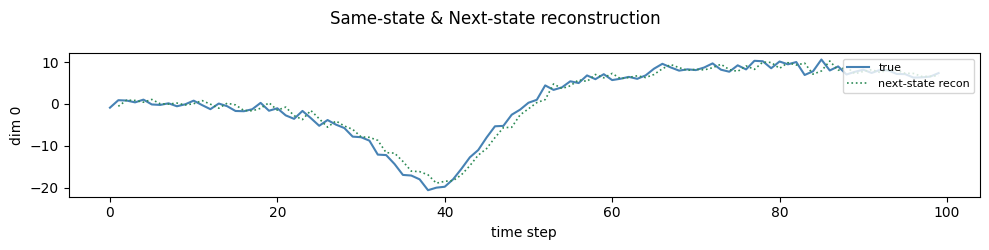

In [ ]:
if lit_model.use_same_state_decoder or lit_model.use_next_state_decoder:
    # Plot reconstructions for first trajectory in batch

    x_np   = x_valid[0].cpu().numpy()    # (T', D)
    n_dims = min(x_np.shape[-1], 3)
    fig, axes = plt.subplots(n_dims, 1, figsize=(10, 2.5 * n_dims), sharex=True)
    if n_dims == 1:
        axes = [axes]
    for d, ax in enumerate(axes):
        ax.plot(x_np[:, d],  label='true',          lw=1.5, color='steelblue')
        if lit_model.use_same_state_decoder:
            xh_np  = x_hat[0].cpu().numpy()      # (T', D)
            ax.plot(xh_np[:, d], label='same-state recon', lw=1.2, color='tomato', ls='--')
        if lit_model.use_next_state_decoder:
            # Next state targets and predictions (align shapes)
            x_next_true = x_valid[0, 1:].cpu().numpy()               # (T'-1, D)
            x_next_pred = x_next_hat[0].cpu().numpy()                # (T'-1, D)
            ax.plot(
                np.arange(1, len(x_np)),   # next-state pred aligns to t+1
                x_next_pred[:, d], 
                label='next-state recon', 
                lw=1.2, color='seagreen', ls=':'
            )
        ax.set_ylabel(f'dim {d}')
        ax.legend(loc='upper right', fontsize=8)
    axes[-1].set_xlabel('time step')
    titles = []
    if lit_model.use_same_state_decoder:
        titles.append('Same-state')
    if lit_model.use_next_state_decoder:
        titles.append('Next-state')
    fig.suptitle(f"{' & '.join(titles)} reconstruction", fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
x_next_true.shape, x_next_pred.shape

((99, 1), (99, 1))

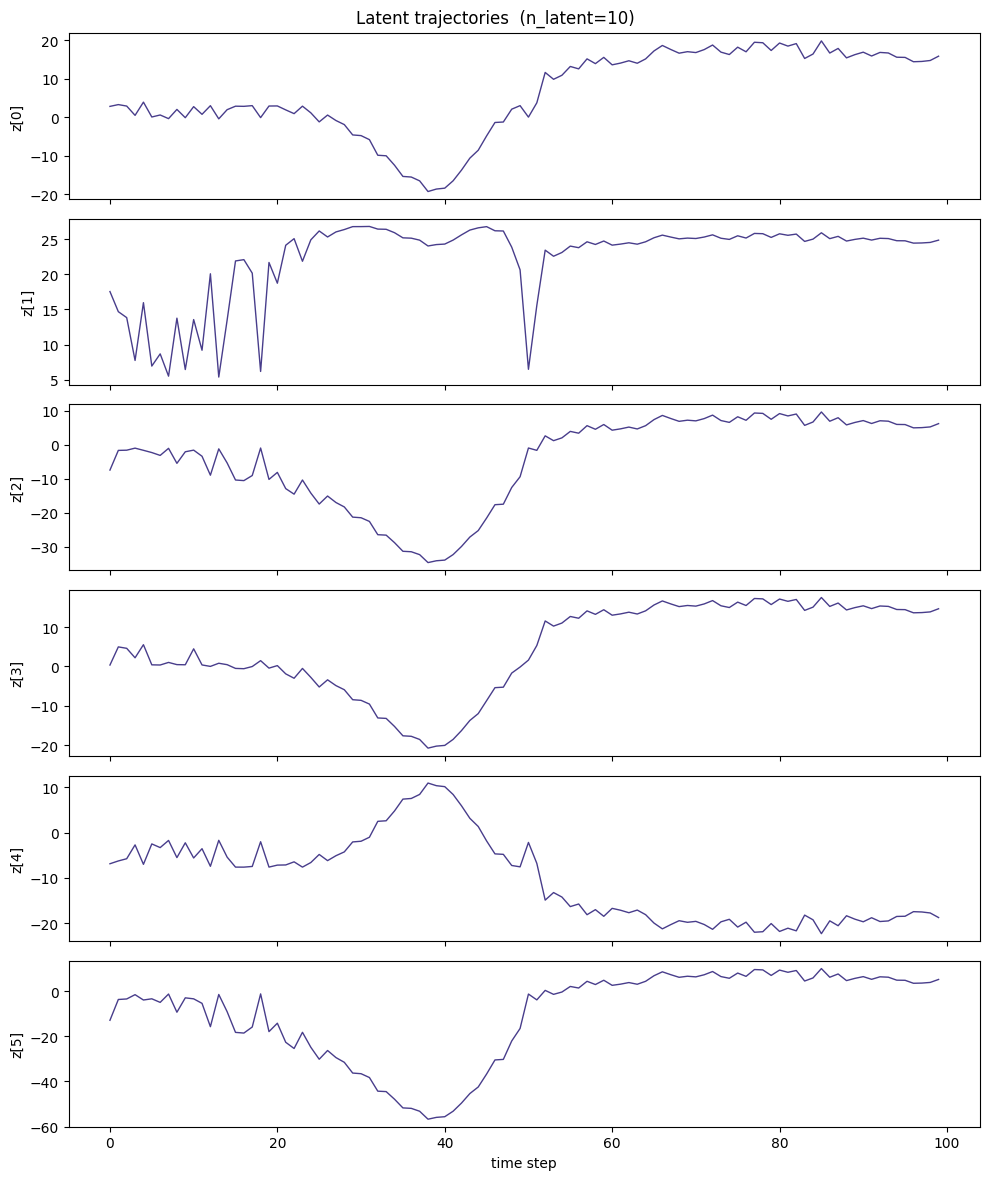

In [ ]:
# ---- Latent trajectory visualisation (first 3 dims) ----
z_np = z_valid[0].cpu().numpy()   # (T', N_LATENT)

n_show = min(z_np.shape[-1], 6)
fig, axes = plt.subplots(n_show, 1, figsize=(10, 2.0 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(z_np[:, i], lw=1, color='darkslateblue')
    ax.set_ylabel(f'z[{i}]')
axes[-1].set_xlabel('time step')
fig.suptitle(f'Latent trajectories  (n_latent={lit_model.n_latent})', fontsize=12)
plt.tight_layout()
plt.show()

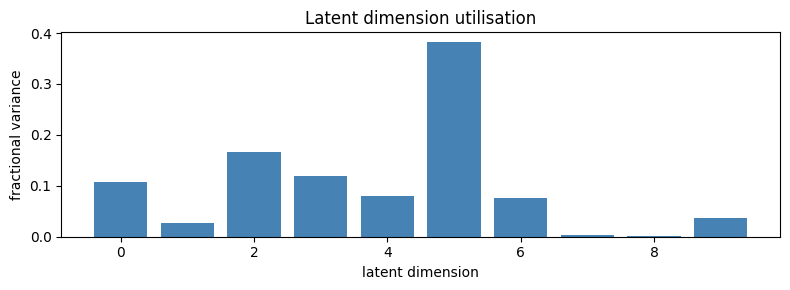

Entropy-based utilization: 0.786  (1.0 = uniform, 0.0 = single dim)


In [ ]:
# ---- Per-dimension variance (latent utilisation) ----
z_all = z_valid.cpu().numpy()   # (B, T', N_LATENT)
dim_var = z_all.reshape(-1, z_all.shape[-1]).var(axis=0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(dim_var)), dim_var / dim_var.sum(), color='steelblue')
ax.set_xlabel('latent dimension')
ax.set_ylabel('fractional variance')
ax.set_title('Latent dimension utilisation')
plt.tight_layout()
plt.show()

import math
p = dim_var / dim_var.sum()
entropy = -np.sum(p * np.log(p + 1e-10))
utilization = entropy / math.log(lit_model.n_latent)
print(f'Entropy-based utilization: {utilization:.3f}  (1.0 = uniform, 0.0 = single dim)')

In [ ]:
# ---- Participation ratio of latent states (PCA-orthogonalized) ----
# Compute participation ratio over principal (PCA) components, not raw coordinates.
from sklearn.decomposition import PCA

z_flat = z_all.reshape(-1, z_all.shape[-1])  # (B*T', N_LATENT)
pca = PCA(n_components=lit_model.n_latent)
z_pca = pca.fit_transform(z_flat)
latent_var_pca = np.var(z_pca, axis=0)  # variance of each PC

pr_pca = (latent_var_pca.sum() ** 2) / (np.sum(latent_var_pca ** 2) + 1e-10)
print(f'Participation ratio (PCA-orthogonalized): {pr_pca:.2f} (of {lit_model.n_latent} total)')


Participation ratio (PCA-orthogonalized): 1.12 (of 10 total)


In [ ]:
z_all.shape

(32, 100, 10)

In [ ]:
z_pca.shape

(3200, 10)

ValueError: s must be a scalar, or float array-like with the same size as x and y

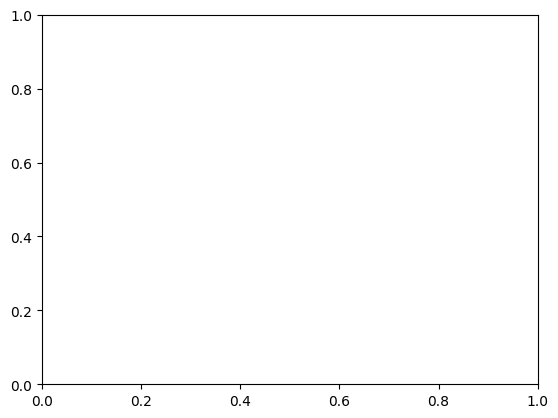

In [ ]:
plt.plot(z_pca[:, 0], z_pca[:, 1], '.')
plt.plot